## Imports

In [371]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
import time

## Load images from GitHub

In [372]:
def get_filename(image_id):
  return f"in{image_id:06d}.jpg"

def get_ground_truth_filename(image_id):
  return f"gt{image_id:06d}.png"

In [373]:
def load_images(url, output_folder, file_count):
  images = []

  os.makedirs(output_folder, exist_ok=True)

  for i in range(1, file_count):
      fileName = get_filename(i)

      full_path = os.path.join(output_folder, fileName)

      if not os.path.exists(full_path):
        r = requests.get(url + fileName, allow_redirects=True)
        open(full_path, "wb").write(r.content)

      img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
      images.append(img)

  print("Loaded", len(images), "images")
  return images

In [374]:
def load_ground_truth(url, output_folder, file_count):
  ground_truth = []

  os.makedirs(output_folder, exist_ok=True)

  for i in range(1, file_count):
      fileName = get_ground_truth_filename(i)

      full_path = os.path.join(output_folder, fileName)

      if not os.path.exists(full_path):
        r = requests.get(url + fileName, allow_redirects=True)
        open(full_path, "wb").write(r.content)

      img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
      ground_truth.append(img)

  print("Loaded", len(ground_truth), "images")
  return ground_truth

In [375]:
url_pedestrian = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/pedestrian/input/"
url_highway = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/highway/input/"
url_office = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/office/input/"

img_pedestrian = load_images(url_pedestrian, "pedestrian", file_count=1100)
img_highway = load_images(url_highway, "highway", file_count=1700)
img_office = load_images(url_office, "office", file_count=2050)

Loaded 1099 images
Loaded 1699 images
Loaded 2049 images


In [376]:
url_pedestrian = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/pedestrian/groundtruth/"
url_highway = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/highway/groundtruth/"
url_office = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/office/groundtruth/"

gt_pedestrian = load_ground_truth(url_pedestrian, "pedestrian", file_count=1100)
gt_highway = load_ground_truth(url_highway, "highway", file_count=1700)
gt_office = load_ground_truth(url_office, "office", file_count=2050)

Loaded 1099 images
Loaded 1699 images
Loaded 2049 images


## Buffer methods

In [377]:
def buffer_method(img_width, img_height, img_list, buf_size, buf_func=np.median):
    buffer = np.zeros((img_height, img_width, buf_size)).astype("uint8")
    buffer_counter = 0
    buffer_full = False

    results = []

    for img in img_list:
        buffer[:, :, buffer_counter] = img
        buffer_counter += 1
        if buffer_counter == buf_size:
            buffer_counter = 0
            buffer_full = True

        if buffer_full:
            result = buf_func(buffer, axis=2).astype("uint8")
            results.append(result)

    return results



### Classification metrics

In [378]:
def precision(image, ground_truth):
    TP = ((image == 255) & (ground_truth == 255)).sum()
    FP = ((image == 255) & (ground_truth == 0)).sum()

    return TP / (TP + FP) if (TP + FP) > 0 else 0


In [379]:
def recall(image, ground_truth):
    TP = ((image == 255) & (ground_truth == 255)).sum()
    FN = ((image == 0) & (ground_truth == 255)).sum()

    return TP / (TP + FN) if (TP + FN) > 0 else 0

In [380]:
def F1_score(image, ground_truth):
  precision_value = precision(image, ground_truth)
  recall_value = recall(image, ground_truth)

  if precision_value + recall_value == 0:
      return 0

  return (2 * precision_value * recall_value) / (precision_value + recall_value)

### Buffer method for pedestrians

In [381]:
img_height, img_width = img_pedestrian[0].shape
pedestrian_median = buffer_method(img_width, img_height, img_pedestrian, 60)
pedestrian_mean = buffer_method(img_width, img_height, img_pedestrian, 60, buf_func=np.mean)
pedestrian_ground_truth = gt_pedestrian

In [428]:
def process_pedestrian_image(image):
  (T, img) = cv2.threshold(image, 22, 255, cv2.THRESH_BINARY)
  img = cv2.medianBlur(img, 5)

  for _ in range(6):
    img = cv2.erode(img, (5, 5))

  for _ in range(10):
    img = cv2.dilate(img, (11, 11))

  return img

#### Visualize both methods

Mean method leaves behind more traces than the median

Text(0.5, 1.0, 'Mean method for image 350')

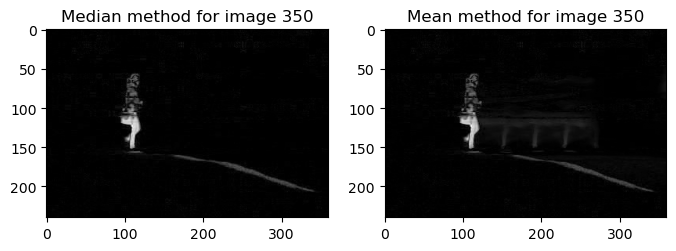

In [383]:
image_id = 350

median_pedestrian_visualization = img_pedestrian[image_id].copy()
median_pedestrian_visualization = abs(median_pedestrian_visualization.astype("int16") - pedestrian_median[image_id]).astype("uint8")

mean_pedestrian_visualization = img_pedestrian[image_id].copy()
mean_pedestrian_visualization = abs(mean_pedestrian_visualization.astype("int16") - pedestrian_mean[image_id]).astype("uint8")

figure, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(median_pedestrian_visualization)
axis[0].set_title(f"Median method for image {image_id}")
axis[1].imshow(mean_pedestrian_visualization)
axis[1].set_title(f"Mean method for image {image_id}")

#### Calculate metrics

In [384]:
p_scores_median = []
r_scores_median = []
f1_scores_median = []

p_scores_mean = []
r_scores_mean = []
f1_scores_mean = []

start, end = 300, 399
for i in range(len(pedestrian_median)):
  if i >= start and i <= end:

    # Median
    current_img = img_pedestrian[i].copy()
    current_img = abs(current_img.astype("int16") - pedestrian_median[i]).astype("uint8")
    current_img = process_pedestrian_image(current_img)

    p_scores_median.append(precision(current_img, pedestrian_ground_truth[i]))
    r_scores_median.append(recall(current_img, pedestrian_ground_truth[i]))
    f1_scores_median.append(F1_score(current_img, pedestrian_ground_truth[i]))

    # Mean
    current_img = img_pedestrian[i].copy()
    current_img = abs(current_img.astype("int16") - pedestrian_mean[i]).astype("uint8")
    current_img = process_pedestrian_image(current_img)

    p_scores_mean.append(precision(current_img, pedestrian_ground_truth[i]))
    r_scores_mean.append(recall(current_img, pedestrian_ground_truth[i]))
    f1_scores_mean.append(F1_score(current_img, pedestrian_ground_truth[i]))

In [385]:
print(sum(p_scores_median) / len(p_scores_median))
print(sum(r_scores_median) / len(r_scores_median))
print(sum(f1_scores_median) / len(f1_scores_median))
print()
print(sum(p_scores_mean) / len(p_scores_mean))
print(sum(r_scores_mean) / len(r_scores_mean))
print(sum(f1_scores_mean) / len(f1_scores_mean))

0.7269841920770539
0.8229147856880971
0.7693339502290313

0.2205487349595382
0.8210324431843806
0.3445458198607975


### Buffer method for office

In [386]:
img_height, img_width = img_office[0].shape
office_median = buffer_method(img_width, img_height, img_office, 60)
office_mean = buffer_method(img_width, img_height, img_office, 60, buf_func=np.mean)
office_ground_truth = gt_office

In [387]:
def fill_holes(image):
    img = image.copy()

    h, w = img.shape
    mask = np.zeros((h+2, w+2), np.uint8)

    cv2.floodFill(img, mask, (0, 0), 255)
    img_inv = cv2.bitwise_not(img)
    filled = image | img_inv

    return filled

In [429]:
def process_office_image(image):
  (T, img) = cv2.threshold(image, 30, 255, cv2.THRESH_BINARY)
  img = cv2.medianBlur(img, 5)

  for _ in range(5):
    img = cv2.dilate(img, (11, 11))

  img = fill_holes(img)

  for _ in range(5):
    img = cv2.erode(img, (5, 5))

  return img

#### Visualize both methods

Mean method leaves behind more traces than the median

Text(0.5, 1.0, 'Mean method for image 700')

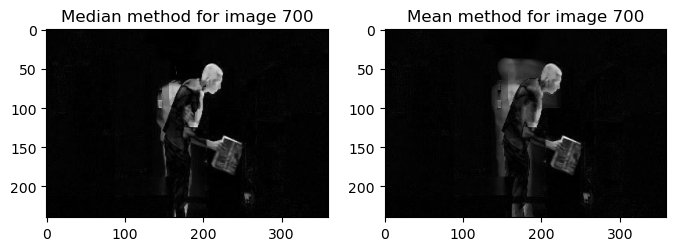

In [389]:
image_id = 700

median_office_visualization = img_office[image_id].copy()
median_office_visualization = abs(median_office_visualization.astype("int16") - office_median[image_id]).astype("uint8")

mean_office_visualization = img_office[image_id].copy()
mean_office_visualization = abs(mean_office_visualization.astype("int16") - office_mean[image_id]).astype("uint8")

figure, axis = plt.subplots(1, 2, figsize=(8, 4))
axis[0].imshow(median_office_visualization)
axis[0].set_title(f"Median method for image {image_id}")
axis[1].imshow(mean_office_visualization)
axis[1].set_title(f"Mean method for image {image_id}")

#### Calculate metrics

In [395]:
p_scores_median = []
r_scores_median = []
f1_scores_median = []

p_scores_mean = []
r_scores_mean = []
f1_scores_mean = []

start, end = 570, 2050
for i in range(len(office_median)):
  if i >= start and i <= end:

    # Median
    current_img = img_office[i].copy()
    current_img = abs(current_img.astype("int16") - office_median[i]).astype("uint8")
    current_img = process_office_image(current_img)

    p_scores_median.append(precision(current_img, office_ground_truth[i]))
    r_scores_median.append(recall(current_img, office_ground_truth[i]))
    f1_scores_median.append(F1_score(current_img, office_ground_truth[i]))

    # Mean
    current_img = img_office[i].copy()
    current_img = abs(current_img.astype("int16") - office_mean[i]).astype("uint8")
    current_img = process_office_image(current_img)

    p_scores_mean.append(precision(current_img, office_ground_truth[i]))
    r_scores_mean.append(recall(current_img, office_ground_truth[i]))
    f1_scores_mean.append(F1_score(current_img, office_ground_truth[i]))

In [396]:
print(sum(p_scores_median) / len(p_scores_median))
print(sum(r_scores_median) / len(r_scores_median))
print(sum(f1_scores_median) / len(f1_scores_median))
print()
print(sum(p_scores_mean) / len(p_scores_mean))
print(sum(r_scores_mean) / len(r_scores_mean))
print(sum(f1_scores_mean) / len(f1_scores_mean))

0.7965314582901408
0.34891538860971893
0.3798159908465524

0.7186130576507846
0.4265416619148462
0.41845833342501854


### Sigma-delta approximation

#### Mean approximation

In [ ]:
def mean_approximation(img_list, alpha=0.01):
    current_BG = img_list[0].copy().astype("float64")
    next_BG = None

    for image in img_list[1:]:
        next_BG = alpha * image + (1 - alpha) * current_BG
        current_BG = next_BG.copy()

    return next_BG.astype("uint8")


#### Comparing different alpha values

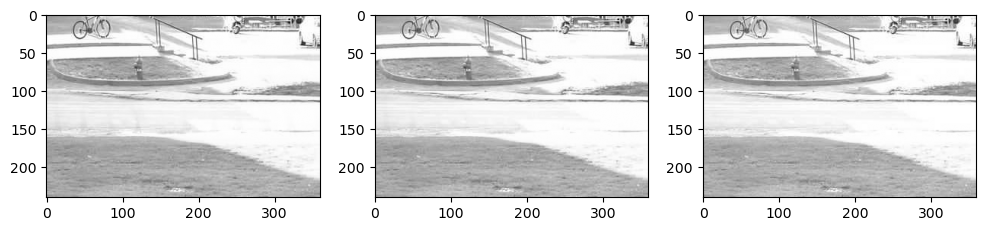

In [398]:
figure, axis = plt.subplots(1, 3, figsize=(12, 4))
axis[0].imshow(mean_approximation(img_pedestrian))
axis[1].imshow(mean_approximation(img_pedestrian, alpha=0.03))
axis[2].imshow(mean_approximation(img_pedestrian, alpha=0.9))

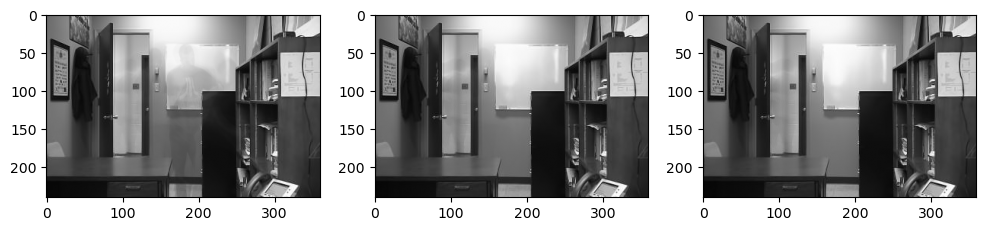

In [399]:
figure, axis = plt.subplots(1, 3, figsize=(12, 4))
axis[0].imshow(mean_approximation(img_office))
axis[1].imshow(mean_approximation(img_office, alpha=0.03))
axis[2].imshow(mean_approximation(img_office, alpha=0.05))

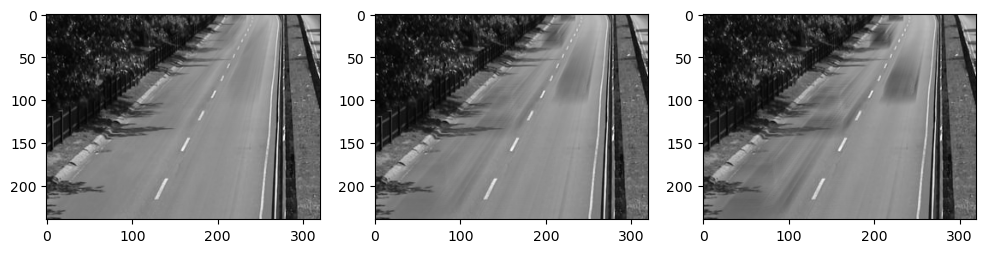

In [400]:
figure, axis = plt.subplots(1, 3, figsize=(12, 4))
axis[0].imshow(mean_approximation(img_highway))
axis[1].imshow(mean_approximation(img_highway, alpha=0.03))
axis[2].imshow(mean_approximation(img_highway, alpha=0.05))

#### Median approximation

In [ ]:
def median_approximation(img_list):
    current_BG = img_list[0].copy()

    for image in img_list[1:]:
        current_BG[current_BG < image] += 1
        current_BG[current_BG > image] -= 1

    return current_BG.astype("uint8")

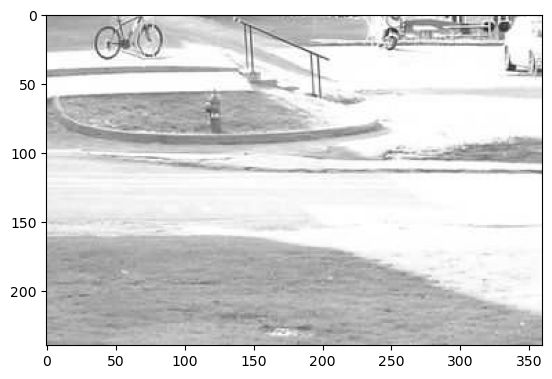

In [402]:
plt.imshow(median_approximation(img_pedestrian))

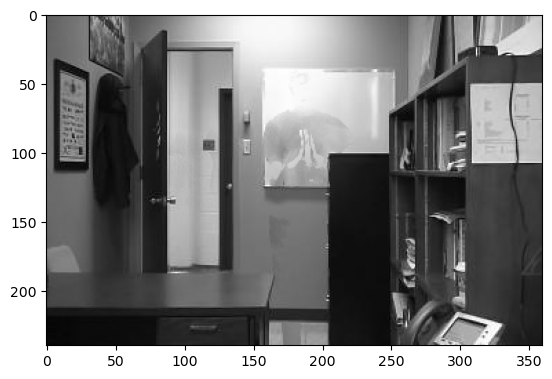

In [403]:
plt.imshow(median_approximation(img_office))

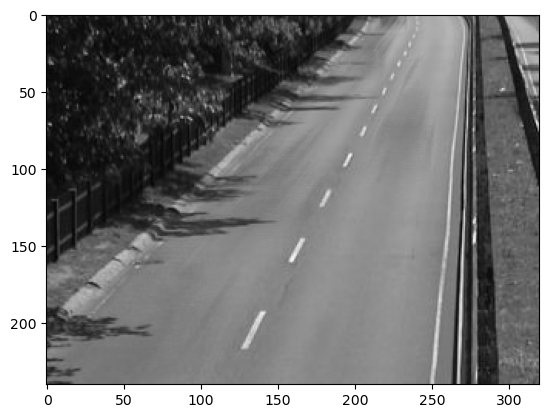

In [404]:
plt.imshow(median_approximation(img_highway))

### Comparing mean and median approximation

#### Pedestrians

In [430]:
start = time.time()
median_approximation_pedestrian = median_approximation(img_pedestrian)
end = time.time()
print(f"Median time: {end - start} seconds.")

start = time.time()
mean_approximation_pedestrian = mean_approximation(img_pedestrian)
end = time.time()
print(f"Mean time: {end - start} seconds.")

p_scores_median = []
r_scores_median = []
f1_scores_median = []

p_scores_mean = []
r_scores_mean = []
f1_scores_mean = []

start, end = 300, 399
for i in range(len(img_pedestrian)):
  if i >= start and i <= end:

    # Median
    current_img = img_pedestrian[i].copy()
    current_img = abs(current_img.astype("int16") - median_approximation_pedestrian).astype("uint8")
    current_img = process_pedestrian_image(current_img)

    p_scores_median.append(precision(current_img, pedestrian_ground_truth[i]))
    r_scores_median.append(recall(current_img, pedestrian_ground_truth[i]))
    f1_scores_median.append(F1_score(current_img, pedestrian_ground_truth[i]))

    # Mean
    current_img = img_pedestrian[i].copy()
    current_img = abs(current_img.astype("int16") - mean_approximation_pedestrian).astype("uint8")
    current_img = process_pedestrian_image(current_img)

    p_scores_mean.append(precision(current_img, pedestrian_ground_truth[i]))
    r_scores_mean.append(recall(current_img, pedestrian_ground_truth[i]))
    f1_scores_mean.append(F1_score(current_img, pedestrian_ground_truth[i]))

Median time: 2.178784132003784 seconds.
Mean time: 1.1720657348632812 seconds.


In [431]:
print(sum(p_scores_median) / len(p_scores_median))
print(sum(r_scores_median) / len(r_scores_median))
print(sum(f1_scores_median) / len(f1_scores_median))
print()
print(sum(p_scores_mean) / len(p_scores_mean))
print(sum(r_scores_mean) / len(r_scores_mean))
print(sum(f1_scores_mean) / len(f1_scores_mean))

0.7403047952591046
0.7800282028201034
0.7554597119737687

0.7541420188799143
0.7798041163647151
0.7640056451869015


#### Office

In [ ]:
start = time.time()
median_approximation_office = median_approximation(img_office)
end = time.time()
print(f"Median time: {end - start} seconds.")

start = time.time()
mean_approximation_office = mean_approximation(img_office)
end = time.time()
print(f"Mean time: {end - start} seconds.")

p_scores_median = []
r_scores_median = []
f1_scores_median = []

p_scores_mean = []
r_scores_mean = []
f1_scores_mean = []

start, end = 570, 2050
for i in range(len(img_office)):
  if i >= start and i <= end:

    # Median
    current_img = img_office[i].copy()
    current_img = abs(current_img.astype("int16") - median_approximation_office).astype("uint8")
    current_img = process_office_image(current_img)

    p_scores_median.append(precision(current_img, office_ground_truth[i]))
    r_scores_median.append(recall(current_img, office_ground_truth[i]))
    f1_scores_median.append(F1_score(current_img, office_ground_truth[i]))

    # Mean
    current_img = img_office[i].copy()
    current_img = abs(current_img.astype("int16") - mean_approximation_office).astype("uint8")
    current_img = process_office_image(current_img)

    p_scores_mean.append(precision(current_img, office_ground_truth[i]))
    r_scores_mean.append(recall(current_img, office_ground_truth[i]))
    f1_scores_mean.append(F1_score(current_img, office_ground_truth[i]))

Median time: 4.782634973526001 seconds.
Mean time: 1.5210418701171875 seconds.


In [433]:
print(sum(p_scores_median) / len(p_scores_median))
print(sum(r_scores_median) / len(r_scores_median))
print(sum(f1_scores_median) / len(f1_scores_median))
print()
print(sum(p_scores_mean) / len(p_scores_mean))
print(sum(r_scores_mean) / len(r_scores_mean))
print(sum(f1_scores_mean) / len(f1_scores_mean))

0.7300312445537822
0.9180127411294353
0.8071811959767288

0.5344691098225728
0.9014582883845852
0.6656299357700505


### Conservative update

In [434]:
def median_approximation_conservative(img_list, threshold=30):
    current_BG = img_list[0].copy()

    for image in img_list[1:]:

        mask = abs(image.astype("int16") - current_BG.astype("int16")) < threshold

        current_BG[(current_BG < image) & mask] += 1
        current_BG[(current_BG > image) & mask] -= 1

    return current_BG.astype("uint8")

#### Comparing background models

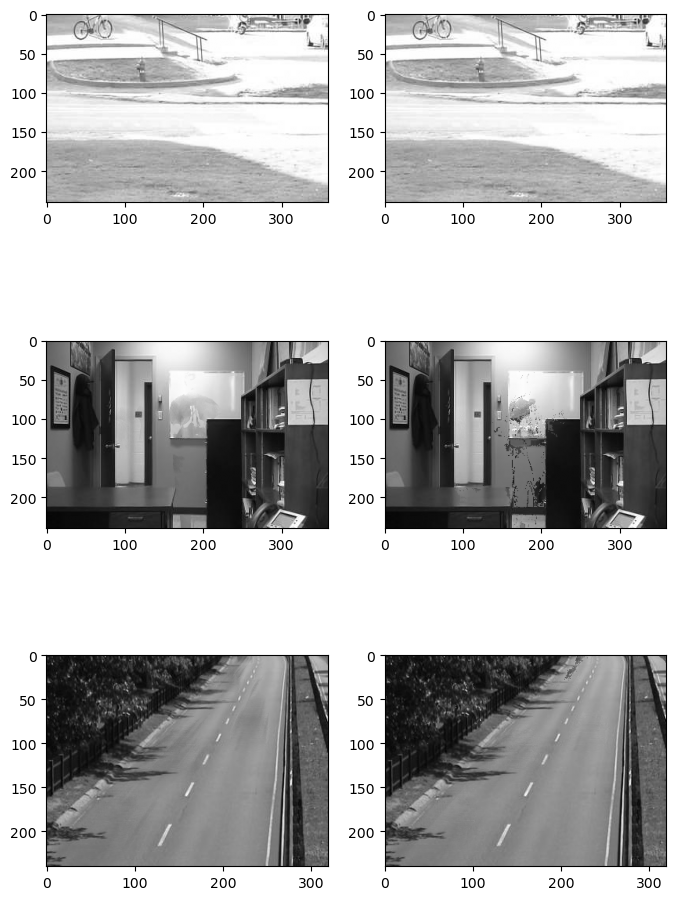

In [436]:
figure, axis = plt.subplots(3, 2, figsize=(8, 12))

axis[0, 0].imshow(median_approximation(img_pedestrian))
axis[0, 1].imshow(median_approximation_conservative(img_pedestrian))

axis[1, 0].imshow(median_approximation(img_office))
axis[1, 1].imshow(median_approximation_conservative(img_office))

axis[2, 0].imshow(median_approximation(img_highway))
axis[2, 1].imshow(median_approximation_conservative(img_highway))

#### Comparing metrics

In [438]:
median_approximation_office = median_approximation(img_office)
median_approximation_conservative_office = median_approximation_conservative(img_office)

p_scores_median = []
r_scores_median = []
f1_scores_median = []

p_scores_mean = []
r_scores_mean = []
f1_scores_mean = []

start, end = 570, 2050
for i in range(len(img_office)):
  if i >= start and i <= end:

    # Median liberal
    current_img = img_office[i].copy()
    current_img = abs(current_img.astype("int16") - median_approximation_office).astype("uint8")
    current_img = process_office_image(current_img)

    p_scores_median.append(precision(current_img, office_ground_truth[i]))
    r_scores_median.append(recall(current_img, office_ground_truth[i]))
    f1_scores_median.append(F1_score(current_img, office_ground_truth[i]))

    # Median conservative
    current_img = img_office[i].copy()
    current_img = abs(current_img.astype("int16") - median_approximation_conservative_office).astype("uint8")
    current_img = process_office_image(current_img)

    p_scores_mean.append(precision(current_img, office_ground_truth[i]))
    r_scores_mean.append(recall(current_img, office_ground_truth[i]))
    f1_scores_mean.append(F1_score(current_img, office_ground_truth[i]))

In [439]:
print(sum(p_scores_median) / len(p_scores_median))
print(sum(r_scores_median) / len(r_scores_median))
print(sum(f1_scores_median) / len(f1_scores_median))
print()
print(sum(p_scores_mean) / len(p_scores_mean))
print(sum(r_scores_mean) / len(r_scores_mean))
print(sum(f1_scores_mean) / len(f1_scores_mean))

0.7300312445537822
0.9180127411294353
0.8071811959767288

0.8332692233074369
0.8790299478845901
0.8474138476943834


### Mixture of Gaussians

In [ ]:
bgSubtractor = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=18,
    detectShadows=False
)

p_scores = []
r_scores = []
f1_scores = []

start, end = 300, 399
for i in range(399):
    
    if start <= i <= end:
        current_img = bgSubtractor.apply(img_pedestrian[i], learningRate=0)
        p_scores.append(precision(current_img, pedestrian_ground_truth[i]))
        r_scores.append(recall(current_img, pedestrian_ground_truth[i]))
        f1_scores.append(F1_score(current_img, pedestrian_ground_truth[i]))
    else:
        current_img = bgSubtractor.apply(img_pedestrian[i], learningRate=0.002)

In [499]:
print(sum(p_scores) / len(p_scores))
print(sum(r_scores) / len(r_scores))
print(sum(f1_scores) / len(f1_scores))

0.8730619603661917
0.8405827769608057
0.8538245340033325


### KNN

In [549]:
bgSubtractor = cv2.createBackgroundSubtractorKNN(
    history=100,
    dist2Threshold=120,
    detectShadows=False
)

p_scores = []
r_scores = []
f1_scores = []

start, end = 300, 399
for i in range(399):
    
    if start <= i <= end:
        current_img = bgSubtractor.apply(img_pedestrian[i], learningRate=0)
        p_scores.append(precision(current_img, pedestrian_ground_truth[i]))
        r_scores.append(recall(current_img, pedestrian_ground_truth[i]))
        f1_scores.append(F1_score(current_img, pedestrian_ground_truth[i]))
    else:
        current_img = bgSubtractor.apply(img_pedestrian[i], learningRate=0.01)

In [550]:
print(sum(p_scores) / len(p_scores))
print(sum(r_scores) / len(r_scores))
print(sum(f1_scores) / len(f1_scores))

0.875770223775679
0.8236456669961909
0.8451247993598383
